In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix


In [55]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = iris.data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [56]:
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
display(df.head())

print("Dataset shape:", df.shape)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Dataset shape: (150, 5)


In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None


In [58]:
print("\nSummary statistics:\n")
display(df.describe())



Summary statistics:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [59]:
possible_non_features = ['Id', 'ID', 'id']
feature_cols = [c for c in df.columns if (c not in possible_non_features) and (df[c].dtype != 'object' or c.lower().startswith('sepal') or c.lower().startswith('petal'))]


In [60]:
label_col = None
for c in df.columns:
    if c.lower() in ('species','class','target'):
        label_col = c
        break

if label_col:
    print("Detected label column:", label_col)
    labels = df[label_col].copy()
else:
    labels = None

Detected label column: species


In [61]:
X = df.select_dtypes(include=[np.number]).copy()
print("Feature columns used:", list(X.columns))
X.head()

Feature columns used: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (150, 4)


In [63]:
wcss = []
sil_scores = []
ks = range(1, 11)

for k in ks:
    # For k=1 silhouette isn't defined; compute inertia but skip silhouette
    if k == 1:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
        km.fit(X_scaled)
        wcss.append(km.inertia_)
        sil_scores.append(np.nan)
    else:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
        labels_k = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)
        sil = silhouette_score(X_scaled, labels_k)
        sil_scores.append(sil)


Text(0.5, 1.0, 'Elbow Method (WCSS)')

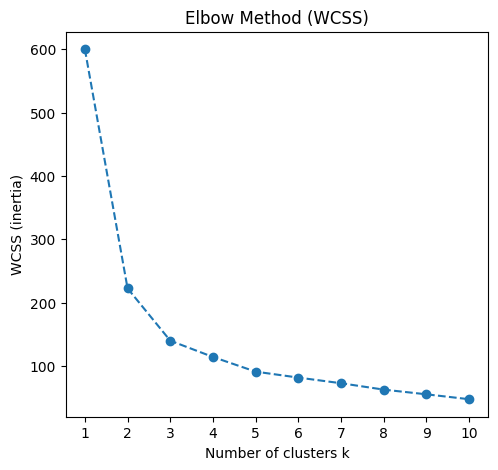

In [64]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ks, wcss, marker='o', linestyle='--')
plt.xticks(ks)
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method (WCSS)')

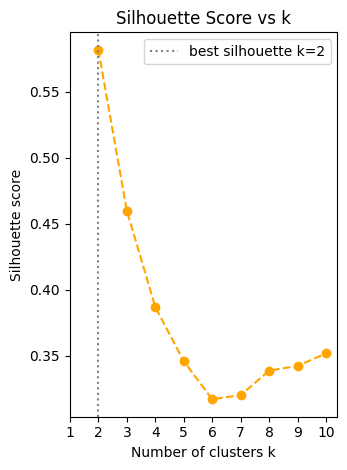

In [65]:
plt.subplot(1,2,2)
plt.plot(ks, sil_scores, marker='o', linestyle='--', color='orange')
plt.xticks(ks)
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score vs k')
plt.axvline(x=ks[np.nanargmax(sil_scores)], color='gray', linestyle=':', label=f'best silhouette k={ks[np.nanargmax(sil_scores)]}')
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
results = pd.DataFrame({'k': ks, 'wcss': wcss, 'silhouette': sil_scores})
display(results)

,k,wcss,silhouette
0,1,600.000000,NaN
1,2,222.361705,0.581750
2,3,139.820496,0.459948
3,4,114.092547,0.386941
4,5,90.927514,0.345901
5,6,81.544391,0.317079
6,7,72.631144,0.320197
7,8,62.540606,0.338692
8,9,55.119493,0.342360
9,10,47.391035,0.351793


In [67]:
chosen_k = 3   # typical for Iris; change to desired value (e.g., 2)
kmeans = KMeans(n_clusters=chosen_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


In [68]:
df_clusters = df.copy()
df_clusters['cluster'] = cluster_labels
display(df_clusters.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [69]:
print("Cluster counts:\n", pd.Series(cluster_labels).value_counts().sort_index())

Cluster counts:
 0    53
1    50
2    47
Name: count, dtype: int64


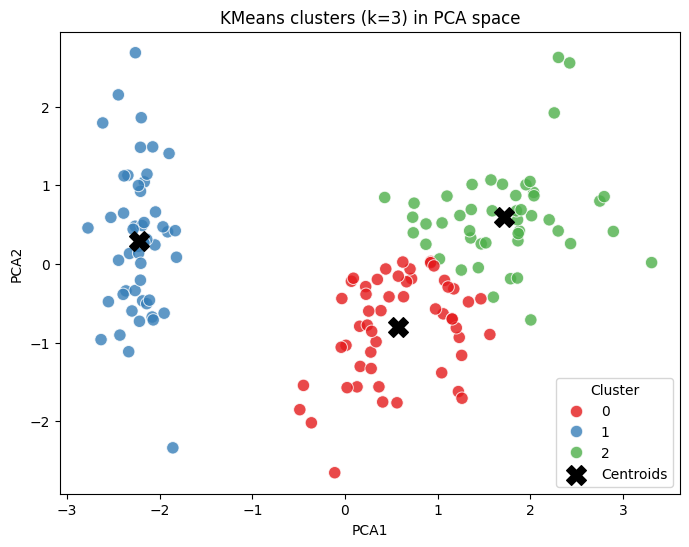

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
palette = sns.color_palette("Set1", n_colors=chosen_k)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette=palette, s=80, alpha=0.8)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:,0], pca.transform(kmeans.cluster_centers_)[:,1],
            marker='X', s=200, c='black', label='Centroids')
plt.title(f'KMeans clusters (k={chosen_k}) in PCA space')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

In [72]:
if labels is not None:
    # If species column is categorical strings, map for clarity
    print("Contingency table (clusters vs true labels):")
    ct = pd.crosstab(df_clusters['cluster'], labels)
    display(ct)

    # Adjusted Rand Index (invariant to label permutations)
    ari = adjusted_rand_score(labels.astype('category').cat.codes if labels.dtype == 'object' else labels, cluster_labels)
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
else:
    print("No true labels detected in dataframe — skipping comparison.")

Contingency table (clusters vs true labels):


species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


Adjusted Rand Index (ARI): 0.6201
